# Predicting House Sale Prices - Ames, Iowa Housing Data

**Author:** Majid M. D Ben Ghet
**Date: ** September 15th 2026

This notebook works through a full data science project: taking a real, messy
real estate dataset, applying varous method of data cleaning, exploring it and drawing conclusions, and building a number of prediction models to
estimate a house's sale price from its characteristics.

## 1. Business Understanding

A real estate analytics team wants a way to estimate a **fair listing price** for a
house before it goes on the market, based on things like its size, condition,
location and age. A model like this would help agents:

- price new listings competitively instead of guessing,
- flag listings that look significantly over- or under-priced compared to similar
  houses,
- give buyers a quick "is this a fair price" sanity check.

**Data source:** the dataset covers 1,460 residential home sales in Ames, Iowa, with
about 80 characteristics recorded for each house (size, quality ratings, garage,
basement, neighborhood, year built, and so on) along with the final sale price.

## 2. Setup
We will first start by importing the relevant libraries to our project.

In [15]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "joblib",
])

0

In [16]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

# make sure the output folders exist before we try to save anything into them
if not os.path.exists("../figures"):
    os.makedirs("../figures")

if not os.path.exists("../models"):
    os.makedirs("../models")

# fixing the random seed so the notebook gives the same results every time it is run
RANDOM_STATE = 42

In [18]:
data_path = "data/AmesHousing.csv"
df = pd.read_csv(data_path)
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Data Understanding

Before doing anything else, we take a first look at the data: how big it is, what
types of columns we have, and where the gaps are.

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [21]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
missing_counts = missing_counts.sort_values(ascending=False)

missing_percent = (missing_counts / len(df)) * 100

print("Columns with missing values:", len(missing_counts))
for column_name in missing_counts.index:
    count = missing_counts[column_name]
    percent = missing_percent[column_name]
    print(column_name, "-", count, "missing (", round(percent, 1), "% )")

Columns with missing values: 19
PoolQC - 1453 missing ( 99.5 % )
MiscFeature - 1406 missing ( 96.3 % )
Alley - 1369 missing ( 93.8 % )
Fence - 1179 missing ( 80.8 % )
MasVnrType - 872 missing ( 59.7 % )
FireplaceQu - 690 missing ( 47.3 % )
LotFrontage - 259 missing ( 17.7 % )
GarageType - 81 missing ( 5.5 % )
GarageYrBlt - 81 missing ( 5.5 % )
GarageFinish - 81 missing ( 5.5 % )
GarageQual - 81 missing ( 5.5 % )
GarageCond - 81 missing ( 5.5 % )
BsmtExposure - 38 missing ( 2.6 % )
BsmtFinType2 - 38 missing ( 2.6 % )
BsmtQual - 37 missing ( 2.5 % )
BsmtCond - 37 missing ( 2.5 % )
BsmtFinType1 - 37 missing ( 2.5 % )
MasVnrArea - 8 missing ( 0.5 % )
Electrical - 1 missing ( 0.1 % )


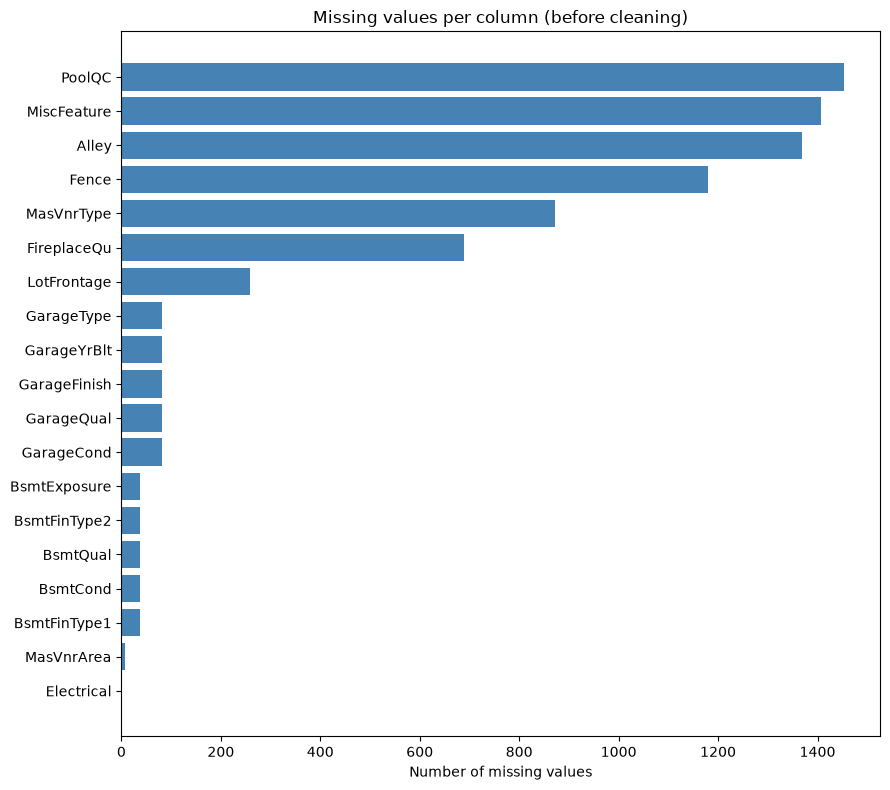

In [22]:
plt.figure(figsize=(9, 8))
plt.barh(missing_counts.index, missing_counts.values, color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Number of missing values")
plt.title("Missing values per column (before cleaning)")
plt.tight_layout()
plt.savefig("../figures/fig_missingness.png", dpi=150)
plt.show()

In [23]:
number_of_duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", number_of_duplicate_rows)

print()
print("Summary of the target variable, SalePrice:")
print(df["SalePrice"].describe())

Number of duplicate rows: 0

Summary of the target variable, SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 4. Data Preparation

Now we clean the dataset column by column, based on what we found above. We try to
make a sensible, documented decision for every group of missing values rather than
just dropping rows or columns.

### 4.1 Columns where "missing" means we have no data for this observation

For these columns, a missing value should become the category `"None"`, not be
imputed with some average value.

In [26]:
columns_missing_means_none = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

for column_name in columns_missing_means_none:
    df[column_name] = df[column_name].fillna("None")

still_missing = df[columns_missing_means_none].isnull().sum().sum()
print("Missing values left in these columns after filling with 'None':", still_missing)

Missing values left in these columns after filling with 'None': 0


### 4.2 LotFrontage - truely missing value

`LotFrontage` is the length of street connected to the property. It is missing for
about 18% of houses. Rather than filling every missing value with one single average,
we estimate it using the **median frontage of houses in the same neighborhood**,
since lot sizes tend to be similar within the same neighborhood.

In [27]:
neighborhood_list = df["Neighborhood"].unique()

for neighborhood_name in neighborhood_list:
    is_this_neighborhood = df["Neighborhood"] == neighborhood_name
    median_frontage = df.loc[is_this_neighborhood, "LotFrontage"].median()

    missing_in_neighborhood = is_this_neighborhood & df["LotFrontage"].isnull()
    df.loc[missing_in_neighborhood, "LotFrontage"] = median_frontage

print("Missing LotFrontage values left:", df["LotFrontage"].isnull().sum())

Missing LotFrontage values left: 0


### 4.3 A few remaining columns

- `GarageYrBlt` (year the garage was built) is missing when there is no garage, so we
  fill it with 0 - this is safe since `GarageType` for these same rows is already
  `"None"`, so the model can tell these houses apart.
- `MasVnrArea` (masonry veneer area) missing almost always means there is no veneer,
  so we fill it with 0 square feet.
- `Electrical` has exactly one missing value. With only one row affected, we simply
  fill it with the most common electrical system in the dataset.

In [28]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

most_common_electrical = df["Electrical"].mode()[0]
df["Electrical"] = df["Electrical"].fillna(most_common_electrical)

print("Total missing values remaining in the whole dataset:", df.isnull().sum().sum())

Total missing values remaining in the whole dataset: 0


### 4.4 Fixing a data type

`MSSubClass` is stored as a number, but it is really a coded category (for example,
20 means a 1-story house built after 1946, 60 means a 2-story house built after
1946). If we leave it as a number, the models will wrongly assume that a higher code
means "more" of something, so we convert it to text and let it be treated as a
category instead.

This information can be found in the Iowa state housing regulations page.

In [29]:
df["MSSubClass"] = df["MSSubClass"].astype(str)

### 4.5 Outliers

A scatter plot of living area against sale price is a good way to spot houses that do
not fit the general pattern.

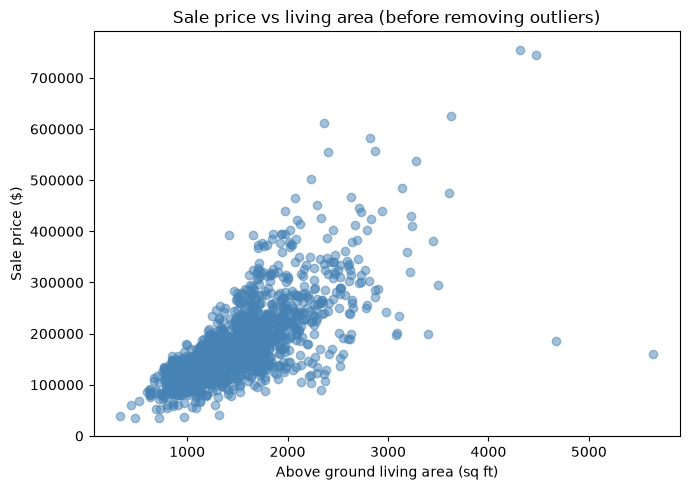

In [30]:
plt.figure(figsize=(7, 5))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5, color="steelblue")
plt.xlabel("Above ground living area (sq ft)")
plt.ylabel("Sale price ($)")
plt.title("Sale price vs living area (before removing outliers)")
plt.tight_layout()
plt.savefig("../figures/fig_outliers_before.png", dpi=150)
plt.show()

In [31]:
outlier_rows = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
print("Outlier rows found:")
print(outlier_rows[["GrLivArea", "SalePrice"]])

df = df.drop(outlier_rows.index)
df = df.reset_index(drop=True)
print("Shape after removing outliers:", df.shape)

Outlier rows found:
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000
Shape after removing outliers: (1458, 81)


There are two houses with a very large living area but a surprisingly low sale
price - almost certainly unusual sales (for example, a bank purchase due to loans or a sale for extraordinary circumstances) rather than
typical market transactions. Left in the data, these two rows would pull a linear
model's fit in the wrong direction, so we remove them.

### 4.6 A few engineered features

A couple of extra columns, built from existing ones, tend to be useful for a housing
price model:

- `TotalSF` - total finished square footage (basement + first floor + second floor)
- `HouseAge` - how old the house was in the year it was sold
- `RemodeledFlag` - whether the house was ever remodeled
- `TotalBath` - total number of bathrooms, counting half bathrooms as 0.5

In [32]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

df["RemodeledFlag"] = 0
was_remodeled = df["YearRemodAdd"] != df["YearBuilt"]
df.loc[was_remodeled, "RemodeledFlag"] = 1

df["TotalBath"] = df["FullBath"] + (0.5 * df["HalfBath"]) + df["BsmtFullBath"] + (0.5 * df["BsmtHalfBath"])

df[["TotalSF", "HouseAge", "RemodeledFlag", "TotalBath"]].head()

,TotalSF,HouseAge,RemodeledFlag,TotalBath
0,2566,5,0,3.5
1,2524,31,0,2.5
2,2706,7,1,3.5
3,2473,91,1,2.0
4,3343,8,0,3.5


Row_ID is just row order numbers and hold no value to the inference.

In [33]:
df = df.drop(columns=[column for column in ["row_id", "Id"] if column in df.columns])
print(df.shape)

(1458, 84)
